In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from numba import njit
%matplotlib inline

# ==========================================
# 1. STRUCTURAL CAPTURE PARAMETERS
# ==========================================
N_ATOMS = 100000       # Scaled down for local laptop testing
BOX_SIZE = 1.0
K_SPRING = 5000.0
MASS = 1.0

DT_INIT = 0.001
DT_MAX = 0.01
N_MIN = 5
F_INC = 1.1
F_DEC = 0.5
ALPHA_START = 0.1
F_ALPHA = 0.99
TOL = 1e-4

MAX_STEPS = 50000     
PHI_TARGET = 0.82     # Marginally jammed state
GAMMA_TARGET = 0.05   # The critical boundary fraction

# Derived parameters
RADIUS = np.sqrt((PHI_TARGET * BOX_SIZE**2) / (N_ATOMS * np.pi))

# FIX: Hardcode GRID_DIVS to 10 so it generates a 10x10 heatmap
GRID_DIVS = 10


In [2]:
# ==========================================
# 2. NUMBA JIT-COMPILED PHYSICS KERNELS
# ==========================================
@njit
def build_cell_list(pos, box_size, cutoff):
    n_atoms = pos.shape[0]
    n_cells = int(np.floor(box_size / cutoff))
    if n_cells < 3: n_cells = 3
    cell_size = box_size / n_cells
    
    head = np.full((n_cells, n_cells), -1, dtype=np.int32)
    next_p = np.full(n_atoms, -1, dtype=np.int32)
    
    for i in range(n_atoms):
        cx = int(pos[i, 0] / cell_size)
        cy = int(pos[i, 1] / cell_size)
        cx = max(0, min(cx, n_cells - 1))
        cy = max(0, min(cy, n_cells - 1))
        next_p[i] = head[cx, cy]
        head[cx, cy] = i
    return head, next_p, n_cells

@njit
def get_forces_cell_list(pos, atom_dt, radius, k_spring, box_size):
    n_atoms = pos.shape[0]
    forces = np.zeros_like(pos)
    forces_dt = np.zeros_like(pos)
    cutoff = 2.0 * radius
    head, next_p, n_cells = build_cell_list(pos, box_size, cutoff)
    
    for cx in range(n_cells):
        for cy in range(n_cells):
            i = head[cx, cy]
            while i != -1:
                for dx in (-1, 0, 1):
                    for dy in (-1, 0, 1):
                        nx = (cx + dx) % n_cells
                        ny = (cy + dy) % n_cells
                        j = head[nx, ny]
                        while j != -1:
                            if i < j:
                                dx_vec = pos[i, 0] - pos[j, 0]
                                dy_vec = pos[i, 1] - pos[j, 1]
                                dx_vec = dx_vec - box_size * np.round(dx_vec / box_size)
                                dy_vec = dy_vec - box_size * np.round(dy_vec / box_size)
                                dist_sq = dx_vec**2 + dy_vec**2
                                
                                if dist_sq < cutoff**2 and dist_sq > 1e-12:
                                    dist = np.sqrt(dist_sq)
                                    f_mag = k_spring * (cutoff - dist)
                                    fx = (dx_vec / dist) * f_mag
                                    fy = (dy_vec / dist) * f_mag
                                    
                                    forces[i, 0] += fx; forces[i, 1] += fy
                                    forces[j, 0] -= fx; forces[j, 1] -= fy
                                    
                                    dt_ij = min(atom_dt[i], atom_dt[j])
                                    forces_dt[i, 0] += fx * dt_ij
                                    forces_dt[i, 1] += fy * dt_ij
                                    forces_dt[j, 0] -= fx * dt_ij
                                    forces_dt[j, 1] -= fy * dt_ij
                            j = next_p[j]
                i = next_p[i]
    return forces, forces_dt

def map_atoms_to_grid(pos, divs):
    ix = np.clip(np.floor(pos[:, 0] * divs).astype(int), 0, divs-1)
    iy = np.clip(np.floor(pos[:, 1] * divs).astype(int), 0, divs-1)
    return ix * divs + iy

In [3]:
# ==========================================
# 3. FIRE ENGINES
# ==========================================
def run_global_fire(pos_init, radius):
    pos = np.copy(pos_init)
    vel = np.zeros_like(pos)
    dt = DT_INIT
    alpha = ALPHA_START
    npos = 0
    
    for step in range(MAX_STEPS):
        atom_dt = np.full(N_ATOMS, dt)
        forces, forces_dt = get_forces_cell_list(pos, atom_dt, radius, K_SPRING, BOX_SIZE)
        vel += 0.5 * forces_dt / MASS
        pos = np.mod(pos + vel * dt, BOX_SIZE)
        
        forces_new, forces_dt_new = get_forces_cell_list(pos, atom_dt, radius, K_SPRING, BOX_SIZE)
        vel += 0.5 * forces_dt_new / MASS
        forces = forces_new
        
        P_global = np.sum(forces * vel)
        v_mag = np.linalg.norm(vel, axis=1, keepdims=True)
        f_mag = np.linalg.norm(forces, axis=1, keepdims=True)
        mask = (f_mag > 1e-12).flatten()
        
        if np.any(mask):
            vel[mask] = (1 - alpha) * vel[mask] + alpha * (forces[mask]/f_mag[mask]) * v_mag[mask]
            
        if P_global > 0:
            npos += 1
            if npos > N_MIN:
                dt = min(dt * F_INC, DT_MAX)
                alpha *= F_ALPHA
        else:
            npos = 0; dt *= F_DEC; vel[:] = 0.0; alpha = ALPHA_START
            
        if step % 500 == 0:
            rms_f = np.sqrt(np.sum(forces**2) / (2 * N_ATOMS))
            if rms_f < TOL:
                print(f"Global FIRE Converged at step {step}")
                break
                
    return pos

def run_async_fire(pos_init, radius, grid_divs):
    pos = np.copy(pos_init)
    vel = np.zeros_like(pos)
    n_domains = grid_divs * grid_divs
    
    d_dt = np.full(n_domains, DT_INIT)
    d_alpha = np.full(n_domains, ALPHA_START)
    d_npos = np.zeros(n_domains, dtype=int)
    
    atom_indices = map_atoms_to_grid(pos, grid_divs)
    forces, forces_dt = get_forces_cell_list(pos, d_dt[atom_indices], radius, K_SPRING, BOX_SIZE)
    
    for step in range(MAX_STEPS):
        vel += 0.5 * forces_dt / MASS
        pos = np.mod(pos + vel * d_dt[atom_indices][:, np.newaxis], BOX_SIZE)
        
        atom_indices = map_atoms_to_grid(pos, grid_divs)
        forces_new, forces_dt_new = get_forces_cell_list(pos, d_dt[atom_indices], radius, K_SPRING, BOX_SIZE)
        vel += 0.5 * forces_dt_new / MASS
        forces = forces_new; forces_dt = forces_dt_new
        
        p_domain = np.bincount(atom_indices, weights=np.sum(forces * vel, axis=1), minlength=n_domains)
        atom_alpha = d_alpha[atom_indices][:, np.newaxis]
        v_mag = np.linalg.norm(vel, axis=1, keepdims=True)
        f_mag = np.linalg.norm(forces, axis=1, keepdims=True)
        mask = (f_mag > 1e-12).flatten()
        
        if np.any(mask): 
            vel[mask] = (1 - atom_alpha[mask]) * vel[mask] + atom_alpha[mask] * (forces[mask]/f_mag[mask]) * v_mag[mask]
            
        mask_up = p_domain > 0
        d_npos[mask_up] += 1
        mask_grow = mask_up & (d_npos > N_MIN)
        d_dt[mask_grow] = np.minimum(d_dt[mask_grow] * F_INC, DT_MAX)
        d_alpha[mask_grow] *= F_ALPHA
        
        mask_down = p_domain <= 0
        d_npos[mask_down] = 0; d_dt[mask_down] *= F_DEC; d_alpha[mask_down] = ALPHA_START
        vel[mask_down[atom_indices]] = 0.0
        
        if step % 500 == 0:
            rms_f = np.sqrt(np.sum(forces**2) / (2 * N_ATOMS))
            if rms_f < TOL:
                print(f"Async FIRE Converged at step {step}")
                break
                
    return pos, forces, d_dt

In [4]:
np.random.seed(42)
print(f"JIT Warming... N={N_ATOMS}, Phi={PHI_TARGET}, K={GRID_DIVS}x{GRID_DIVS}")
_ = get_forces_cell_list(np.random.rand(10,2), np.ones(10), RADIUS, K_SPRING, BOX_SIZE)

print("\n--- Running Global FIRE ---")
pos_init = np.random.rand(N_ATOMS, 2)
pos_glob = run_global_fire(pos_init, RADIUS)

print("\n--- Running Async FIRE ---")
pos_async, forces_async, d_dt_final = run_async_fire(pos_init, RADIUS, GRID_DIVS)

print("\nSimulation complete. Data stored in memory for rendering.")

JIT Warming... N=100000, Phi=0.82, K=10x10

--- Running Global FIRE ---
Global FIRE Converged at step 500

--- Running Async FIRE ---
Async FIRE Converged at step 500

Simulation complete. Data stored in memory for rendering.


In [5]:
@njit
def calculate_gr_numba(pos, box_size, radius, bins=100, r_max=4.0):
    r_max_scaled = r_max * (2*radius)
    hist = np.zeros(bins)
    edges = np.linspace(0, r_max_scaled, bins+1)
    dr = edges[1] - edges[0]
    n_pts = pos.shape[0]

    for i in range(n_pts):
        for j in range(i+1, n_pts):
            dx = pos[i, 0] - pos[j, 0]
            dy = pos[i, 1] - pos[j, 1]
            dx = dx - box_size * np.round(dx / box_size)
            dy = dy - box_size * np.round(dy / box_size)
            dist = np.sqrt(dx**2 + dy**2)
            
            if dist < r_max_scaled and dist > 1e-8:
                idx = int(dist / dr)
                if idx < bins:
                    hist[idx] += 2.0  # +2 accounts for i->j and j->i
                    
    r_centers = 0.5 * (edges[1:] + edges[:-1])
    density = n_pts / (box_size**2)
    ideal_counts = 2 * np.pi * r_centers * dr * density * n_pts
    gr = hist / ideal_counts
    return r_centers / (2*radius), gr

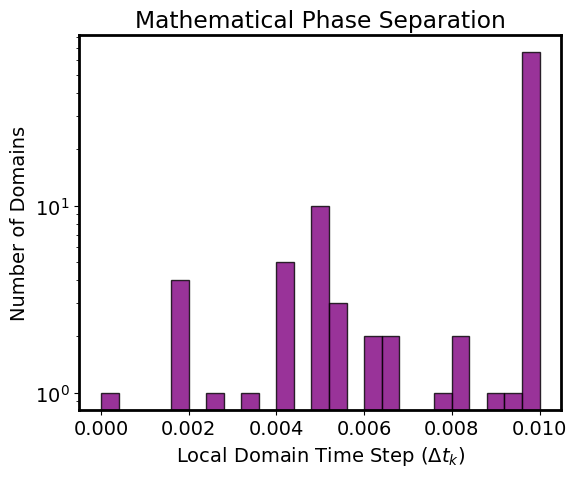

In [6]:
plt.rcParams.update({'font.size': 14, 'axes.linewidth': 2})

fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.hist(d_dt_final, bins=25, color='purple', edgecolor='black', alpha=0.8)
ax1.set_yscale('log')
ax1.set_xlabel(r"Local Domain Time Step ($\Delta t_k$)")
ax1.set_ylabel("Number of Domains")
ax1.set_title("Mathematical Phase Separation")
plt.tight_layout()
plt.show()

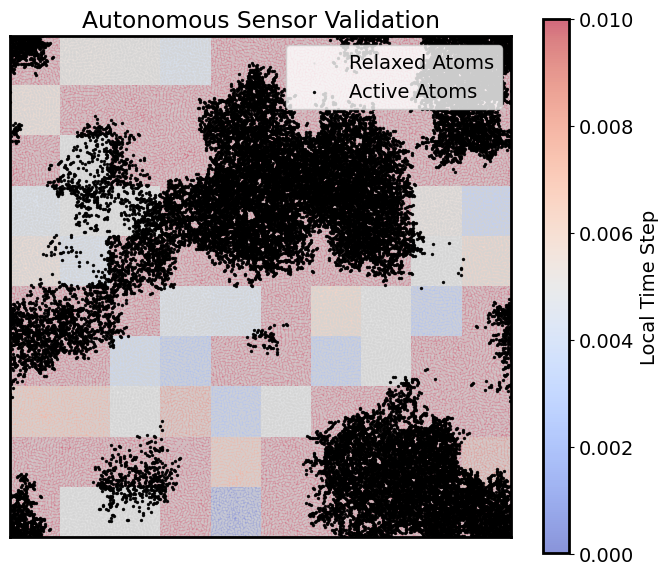

In [7]:
fig2, ax2 = plt.subplots(figsize=(7, 6))

# 1. Plot the Heatmap (Now an actual 10x10 grid!)
dt_grid = d_dt_final.reshape((GRID_DIVS, GRID_DIVS)).T
im = ax2.imshow(dt_grid, extent=[0, BOX_SIZE, 0, BOX_SIZE], origin='lower', 
                cmap='coolwarm', alpha=0.6)
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label("Local Time Step")

# 2. Calculate the active threshold
force_mags = np.linalg.norm(forces_async, axis=1)
active_mask = force_mags > (np.mean(force_mags) * 0.5) 

# 3. FIX: Plot ALL atoms first in light grey (The full system)
ax2.scatter(pos_async[:, 0], pos_async[:, 1], 
            s=0.5, c='lightgray', alpha=0.5, label='Relaxed Atoms')

# 4. FIX: Plot the active atoms on top in black
ax2.scatter(pos_async[active_mask, 0], pos_async[active_mask, 1], 
            s=2.0, c='black', alpha=0.9, label='Active Atoms')

# 5. Formatting
ax2.set_xlim(0, BOX_SIZE)
ax2.set_ylim(0, BOX_SIZE)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title("Autonomous Sensor Validation")
ax2.legend(loc="upper right") # Added legend to confirm it ran!
plt.tight_layout()
plt.show()

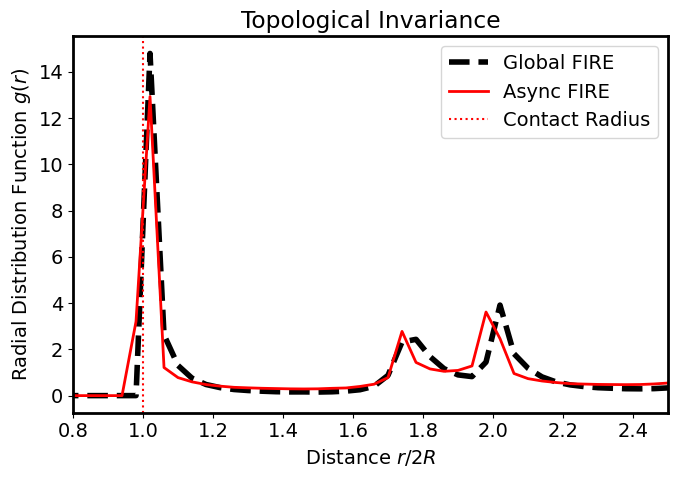

In [8]:
fig3, ax3 = plt.subplots(figsize=(7, 5))
r_async, gr_async = calculate_gr_numba(pos_async, BOX_SIZE, RADIUS)
r_glob, gr_glob = calculate_gr_numba(pos_glob, BOX_SIZE, RADIUS)

ax3.plot(r_glob, gr_glob, 'k--', linewidth=4, label='Global FIRE')
ax3.plot(r_async, gr_async, 'r-', linewidth=2, label='Async FIRE')
ax3.axvline(x=1.0, color='red', linestyle=':', linewidth=1.5, label='Contact Radius')

ax3.set_xlim(0.8, 2.5)
ax3.set_xlabel(r"Distance $r/2R$")
ax3.set_ylabel(r"Radial Distribution Function $g(r)$")
ax3.set_title("Topological Invariance")
ax3.legend()
plt.tight_layout()
plt.show()